In [42]:
%pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/150.0 MB 1.7 MB/s eta 0:01:31
   ---------------------------------------- 0.5/150.0 MB 4.2 MB/s eta 0:00:36
   ---------------------------------------- 1.1/150.0 MB 7.2 MB/s eta 0:00:21
   ---------------------------------------- 1.7/150.0 MB 8.4 MB/s eta 0:00:18
    --------------------------------------- 2.3/150.0 MB 9.3 MB/s eta 0:00:16
    --------------------------------------- 2.9/150.0 MB 9.2 MB/s eta 0:00:17
    --------------------------------------- 3.6/150.0 MB 9.9 MB/s eta 0:00:15
   - -------------------------------------- 4.0/150.0 MB 9.8 MB/s eta 0:00:15
   - -------------------------------------- 4.5/150.0 MB 9.8 MB/s eta 0:00:15
   - -------------------------------------- 4.9/150.0 MB 9.9 MB/s eta 0:00:15
   - -------------------------------------- 5.6/150.0 MB 10.2 MB/s eta 0:00:15


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\santy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import KernelPCA

In [21]:
data = pd.read_csv('../data/processed/datos.csv')

data.head()

,frame,label,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,...,landmark_29_z,landmark_30_x,landmark_30_y,landmark_30_z,landmark_31_x,landmark_31_y,landmark_31_z,landmark_32_x,landmark_32_y,landmark_32_z
0,1.0,caminar,0.522302,0.300907,-0.259125,0.528479,0.295276,-0.240778,0.532583,0.295422,...,0.176763,0.491534,0.544477,0.154332,0.562083,0.554709,0.055493,0.480301,0.554012,0.025167
1,3.0,caminar,0.522325,0.300934,-0.258680,0.528482,0.295276,-0.240664,0.532614,0.295422,...,0.176082,0.491611,0.544355,0.151797,0.562076,0.554997,0.049002,0.480776,0.554354,0.020594
2,5.0,caminar,0.522075,0.300966,-0.244616,0.528257,0.295300,-0.227193,0.532477,0.295451,...,0.175261,0.492032,0.544336,0.151791,0.562040,0.555176,0.046642,0.480779,0.555362,0.020609
3,7.0,caminar,0.521994,0.301157,-0.242839,0.528174,0.295446,-0.225212,0.532432,0.295585,...,0.169674,0.492209,0.544346,0.143386,0.562010,0.555493,0.038787,0.481464,0.556107,0.010090
4,9.0,caminar,0.521980,0.301355,-0.241620,0.528162,0.295611,-0.223816,0.532429,0.295754,...,0.166118,0.492920,0.544385,0.142316,0.561882,0.555633,0.035620,0.482965,0.556262,0.009404


In [22]:
from sklearn.preprocessing import StandardScaler

# Crear una instancia de StandardScaler
scaler = StandardScaler()

# Seleccionar las columnas que deseas normalizar (excluyendo las columnas no numéricas si es necesario)
columns_to_normalize = data.select_dtypes(include=['float64', 'int64']).columns

# Resetear el índice del DataFrame para asegurar que los índices sean únicos
data_reset = data.reset_index(drop=True)

# Normalizar los datos
normalized_data = scaler.fit_transform(data_reset[columns_to_normalize])

# Crear un nuevo DataFrame con los datos normalizados
normalized_df = pd.DataFrame(normalized_data, columns=columns_to_normalize)

# Si deseas mantener las columnas no numéricas, puedes concatenarlas con el DataFrame normalizado
result_df_normalized = pd.concat([data_reset.drop(columns=columns_to_normalize), normalized_df], axis=1)

# Mostrar el DataFrame normalizado
data = result_df_normalized

data

,label,frame,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,...,landmark_29_z,landmark_30_x,landmark_30_y,landmark_30_z,landmark_31_x,landmark_31_y,landmark_31_z,landmark_32_x,landmark_32_y,landmark_32_z
0,caminar,-1.092105,0.327986,0.613494,0.114944,0.313786,0.664132,0.189630,0.302531,0.664557,...,-0.192724,0.517938,-1.929018,-0.343188,0.284586,-1.982434,-0.058390,0.526546,-1.986355,-0.226860
1,caminar,-1.068706,0.328324,0.613761,0.116327,0.313832,0.664133,0.190022,0.303031,0.664552,...,-0.194749,0.519074,-1.930110,-0.350663,0.284509,-1.979963,-0.076572,0.531760,-1.983423,-0.239492
2,caminar,-1.045307,0.324500,0.614079,0.160004,0.310244,0.664366,0.236637,0.300849,0.664839,...,-0.197192,0.525224,-1.930279,-0.350681,0.284109,-1.978425,-0.083184,0.531783,-1.974780,-0.239450
3,caminar,-1.021907,0.323267,0.615948,0.165523,0.308911,0.665762,0.243493,0.300135,0.666124,...,-0.213815,0.527809,-1.930187,-0.375461,0.283775,-1.975699,-0.105189,0.539301,-1.968389,-0.268503
4,caminar,-0.998508,0.323053,0.617892,0.169307,0.308731,0.667350,0.248323,0.300083,0.667748,...,-0.224396,0.538219,-1.929845,-0.378616,0.282356,-1.974500,-0.114062,0.555760,-1.967059,-0.270395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5553,sentarse,-0.132726,0.549230,1.182909,0.190721,0.675527,1.173339,0.303434,0.730360,1.179927,...,-1.629621,-0.643267,0.940394,-1.593085,1.334217,1.136740,-1.718420,-0.785413,1.151573,-1.618437
5554,sentarse,-0.109327,0.532288,1.183573,0.149943,0.652789,1.171435,0.275020,0.705640,1.177475,...,-1.707009,-0.642734,0.935279,-1.623029,1.329135,1.137576,-1.841377,-0.790900,1.151697,-1.682999
5555,sentarse,-0.085927,0.511694,1.181660,0.149589,0.630468,1.168179,0.267812,0.679822,1.174199,...,-1.702882,-0.642158,0.924734,-1.605264,1.313028,1.138171,-1.835043,-0.796569,1.148480,-1.656188
5556,sentarse,-0.062528,0.492232,1.176546,0.147115,0.606375,1.161936,0.261419,0.649733,1.168290,...,-1.714736,-0.639773,0.918275,-1.571440,1.304462,1.138534,-1.839336,-0.805662,1.143619,-1.615032


Varianza explicada por cada componente principal:
Componente 1: 0.3235
Componente 2: 0.1965
Componente 3: 0.1770
Componente 4: 0.1334
Componente 5: 0.0658
Componente 6: 0.0383
Componente 7: 0.0181
Componente 8: 0.0093
Componente 9: 0.0089
Componente 10: 0.0048
Componente 11: 0.0041
Componente 12: 0.0036
Componente 13: 0.0033
Componente 14: 0.0020
Componente 15: 0.0018
Componente 16: 0.0015
Componente 17: 0.0012
Componente 18: 0.0011


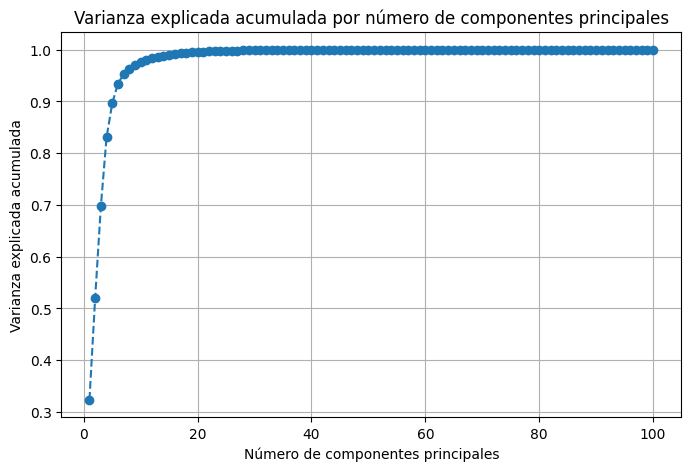

In [23]:
#Calcular la varianza explicada acumulada
data_2=data.drop('label', axis=1)
X = StandardScaler().fit_transform(data_2)
pca = PCA()  # Reduce to 2 dimensions for visualization
pca.fit(X)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

#Imprimir la varianza explicada por cada componente principal
print("Varianza explicada por cada componente principal:")
for i, var_exp in enumerate(explained_variance_ratio):
  if var_exp > 0.001:
    print(f"Componente {i + 1}: {var_exp:.4f}")

#Graficar la varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza explicada acumulada por número de componentes principales')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.show()

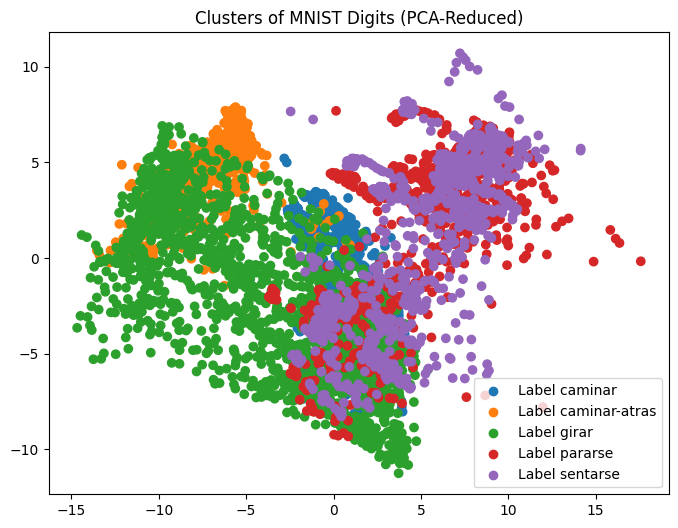

In [24]:
labels = data['label']

data_2=data.drop('label', axis=1)

X = StandardScaler().fit_transform(data_2)

pca = PCA(n_components=8)  # Reduce to 2 dimensions for visualization
reduced_data = pca.fit_transform(X)

# Create a color map for each unique label
unique_labels = labels.unique()
label_colors = {label: plt.get_cmap('tab10')(i) for i, label in enumerate(unique_labels)}

# Assign colors to data points based on their labels
colors = [label_colors[label] for label in labels]


plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=colors)
plt.title("Clusters of MNIST Digits (PCA-Reduced)")

# Create a legend to show which color represents each label
for label, color in label_colors.items():
  plt.scatter([], [], color=color, label=f'Label {label}')

plt.legend()
plt.show()

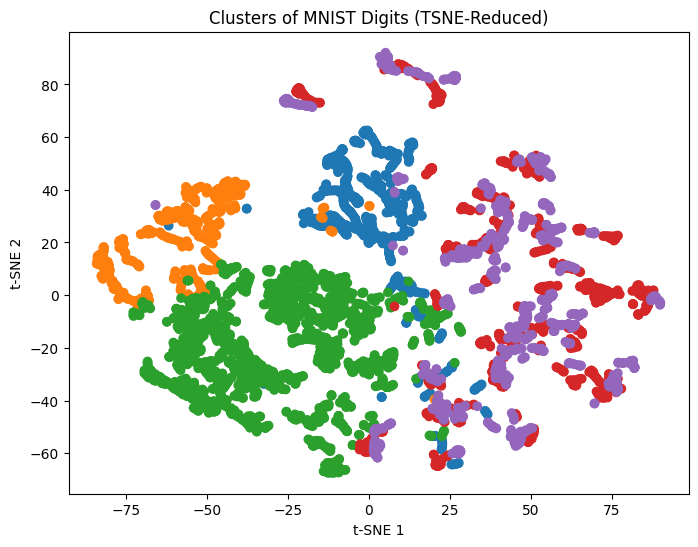

In [26]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, init='pca')
tsne_features = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=colors)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title("Clusters of MNIST Digits (TSNE-Reduced)")

# Create a legend to show which color represents each label
for label, color in label_colors.items():
  plt.scatter([], [], color=color, label=f'Label {label}')

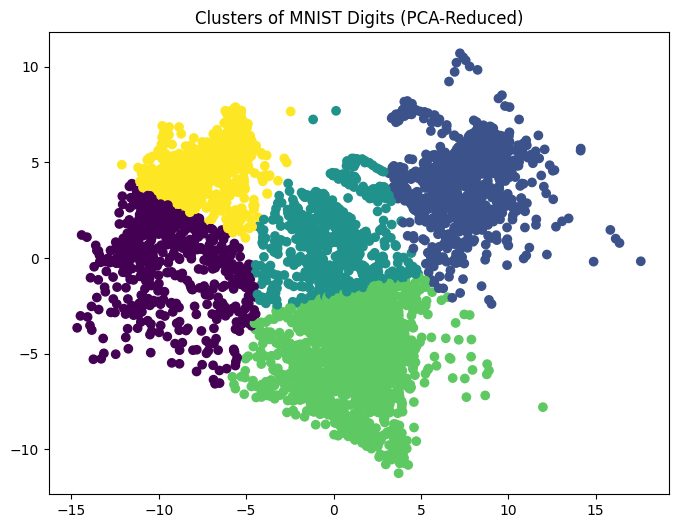

In [27]:
labels = data['label']

data_2=data.drop('label', axis=1)

X = StandardScaler().fit_transform(data_2)

pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
reduced_data = pca.fit_transform(X)
kmeans = KMeans(n_clusters=5, random_state=0,n_init=2)  # 10 clusters for 10 digits
cluster_labels = kmeans.fit_predict(reduced_data)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='viridis')
plt.title("Clusters of MNIST Digits (PCA-Reduced)")
plt.show()

In [28]:
result_data = []

# Agrupar por el label
df = data.copy()

grouped = df.groupby('label')

for label, group in grouped:
    # Tomar grupos de 5 frames
    for i in range(0, len(group), 5):
        # Tomar un grupo de 5 frames
        frame_group = group.iloc[i:i + 5]

        # Verificar si hay menos de 5 frames
        if len(frame_group) < 5:
            continue  # Saltar si no hay suficientes frames para completar el grupo

        # Crear un diccionario para almacenar los datos de este grupo
        aggregated_data = {'label': label}

        # Agregar los landmarks de los frames
        for j in range(33):  # Hay 33 landmarks en MediaPipe Pose
            # Obtener las coordenadas x, y, z de cada landmark para cada uno de los 5 frames
            for k in range(5):  # k de 0 a 4 para los 5 frames
                aggregated_data[f'landmark_{j}_x_frame_{k+1}'] = frame_group.iloc[k][f'landmark_{j}_x']
                aggregated_data[f'landmark_{j}_y_frame_{k+1}'] = frame_group.iloc[k][f'landmark_{j}_y']
                aggregated_data[f'landmark_{j}_z_frame_{k+1}'] = frame_group.iloc[k][f'landmark_{j}_z']

        # Agregar el resultado a la lista
        result_data.append(aggregated_data)

# Convertir la lista de resultados a un DataFrame
result_df = pd.DataFrame(result_data)

result_df

,label,landmark_0_x_frame_1,landmark_0_y_frame_1,landmark_0_z_frame_1,landmark_0_x_frame_2,landmark_0_y_frame_2,landmark_0_z_frame_2,landmark_0_x_frame_3,landmark_0_y_frame_3,landmark_0_z_frame_3,...,landmark_32_z_frame_2,landmark_32_x_frame_3,landmark_32_y_frame_3,landmark_32_z_frame_3,landmark_32_x_frame_4,landmark_32_y_frame_4,landmark_32_z_frame_4,landmark_32_x_frame_5,landmark_32_y_frame_5,landmark_32_z_frame_5
0,caminar,0.327986,0.613494,0.114944,0.328324,0.613761,0.116327,0.324500,0.614079,0.160004,...,-0.239492,0.531783,-1.974780,-0.239450,0.539301,-1.968389,-0.268503,0.555760,-1.967059,-0.270395
1,caminar,0.323235,0.621178,0.181826,0.323824,0.623640,0.168749,0.325682,0.627690,0.132569,...,-0.260414,0.566596,-1.960327,-0.258495,0.566668,-1.959479,-0.269541,0.566307,-1.958937,-0.272572
2,caminar,0.337418,0.636222,0.100295,0.380654,0.637807,0.027712,0.407425,0.638617,0.001507,...,-0.285998,0.569787,-1.956986,-0.280207,0.580188,-1.958707,-0.276460,0.581722,-1.959334,-0.265192
3,caminar,0.578782,0.639321,-0.033365,0.600966,0.637125,-0.078038,0.607618,0.630505,-0.130706,...,-0.148898,0.653535,-1.967699,-0.182908,0.655733,-1.949642,-0.257124,0.684913,-1.946214,-0.269594
4,caminar,0.588801,0.627684,-0.111455,0.538433,0.629438,-0.157515,0.449209,0.626140,-0.211001,...,-0.350811,0.765593,-1.896774,-0.452366,0.749633,-1.876744,-0.376458,0.740550,-1.862409,-0.232138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,sentarse,0.279322,-0.697884,-0.839274,0.266578,-0.404727,-1.413810,0.238591,-0.091188,-1.608330,...,1.128311,-0.626022,1.220529,1.015838,-0.627784,1.220320,0.832220,-0.634610,1.220944,-0.271616
1106,sentarse,0.095680,0.985940,-0.909324,0.048073,1.258696,-0.398990,-0.027028,1.482454,-0.273988,...,-0.714023,-0.724402,1.208314,-1.033981,-0.740027,1.208751,-1.385679,-0.741068,1.206616,-1.067975
1107,sentarse,0.024728,1.688010,0.062033,0.059675,1.655664,0.051522,0.130567,1.567286,0.032388,...,-1.588306,-0.746104,1.172651,-2.090012,-0.758494,1.169162,-1.912043,-0.791975,1.168245,-1.637054
1108,sentarse,0.284631,1.419124,0.081737,0.323233,1.374331,0.078019,0.430167,1.320332,0.134730,...,-1.622532,-0.779700,1.153536,-1.560251,-0.774193,1.147570,-1.516042,-0.771582,1.148021,-1.680585


In [29]:
data.shape

(5558, 101)

In [30]:
result_data = []

# Agrupar por el label
grouped = df.groupby('label')

for label, group in grouped:
    # Tomar grupos de 5 frames con solapamientos
    for i in range(len(group) - 4):  # -4 para asegurarnos de que haya al menos 5 frames
        # Tomar un grupo de 5 frames
        frame_group = group.iloc[i:i + 5]

        # Crear un diccionario para almacenar los datos de este grupo
        aggregated_data = {'label': label}

        # Agregar los landmarks de los frames
        for j in range(33):  # Hay 33 landmarks en MediaPipe Pose
            # Obtener las coordenadas x, y, z de cada landmark para cada uno de los 5 frames
            for k in range(5):  # k de 0 a 4 para los 5 frames
                aggregated_data[f'landmark_{j}_x_frame_{k+1}'] = frame_group.iloc[k][f'landmark_{j}_x']
                aggregated_data[f'landmark_{j}_y_frame_{k+1}'] = frame_group.iloc[k][f'landmark_{j}_y']
                aggregated_data[f'landmark_{j}_z_frame_{k+1}'] = frame_group.iloc[k][f'landmark_{j}_z']

        # Agregar el resultado a la lista
        result_data.append(aggregated_data)

# Convertir la lista de resultados a un DataFrame
result_df_2 = pd.DataFrame(result_data)

result_df_2.shape

(5538, 496)

In [31]:
result_df_2

,label,landmark_0_x_frame_1,landmark_0_y_frame_1,landmark_0_z_frame_1,landmark_0_x_frame_2,landmark_0_y_frame_2,landmark_0_z_frame_2,landmark_0_x_frame_3,landmark_0_y_frame_3,landmark_0_z_frame_3,...,landmark_32_z_frame_2,landmark_32_x_frame_3,landmark_32_y_frame_3,landmark_32_z_frame_3,landmark_32_x_frame_4,landmark_32_y_frame_4,landmark_32_z_frame_4,landmark_32_x_frame_5,landmark_32_y_frame_5,landmark_32_z_frame_5
0,caminar,0.327986,0.613494,0.114944,0.328324,0.613761,0.116327,0.324500,0.614079,0.160004,...,-0.239492,0.531783,-1.974780,-0.239450,0.539301,-1.968389,-0.268503,0.555760,-1.967059,-0.270395
1,caminar,0.328324,0.613761,0.116327,0.324500,0.614079,0.160004,0.323267,0.615948,0.165523,...,-0.239450,0.539301,-1.968389,-0.268503,0.555760,-1.967059,-0.270395,0.556409,-1.963077,-0.269760
2,caminar,0.324500,0.614079,0.160004,0.323267,0.615948,0.165523,0.323053,0.617892,0.169307,...,-0.268503,0.555760,-1.967059,-0.270395,0.556409,-1.963077,-0.269760,0.565943,-1.960975,-0.260414
3,caminar,0.323267,0.615948,0.165523,0.323053,0.617892,0.169307,0.323235,0.621178,0.181826,...,-0.270395,0.556409,-1.963077,-0.269760,0.565943,-1.960975,-0.260414,0.566596,-1.960327,-0.258495
4,caminar,0.323053,0.617892,0.169307,0.323235,0.621178,0.181826,0.323824,0.623640,0.168749,...,-0.269760,0.565943,-1.960975,-0.260414,0.566596,-1.960327,-0.258495,0.566668,-1.959479,-0.269541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5533,sentarse,0.568329,1.217090,0.185015,0.577946,1.206230,0.174672,0.564113,1.187085,0.192207,...,-1.635929,-0.748342,1.148089,-1.606045,-0.761761,1.151437,-1.631637,-0.785413,1.151573,-1.618437
5534,sentarse,0.577946,1.206230,0.174672,0.564113,1.187085,0.192207,0.557879,1.179995,0.212994,...,-1.606045,-0.761761,1.151437,-1.631637,-0.785413,1.151573,-1.618437,-0.790900,1.151697,-1.682999
5535,sentarse,0.564113,1.187085,0.192207,0.557879,1.179995,0.212994,0.549230,1.182909,0.190721,...,-1.631637,-0.785413,1.151573,-1.618437,-0.790900,1.151697,-1.682999,-0.796569,1.148480,-1.656188
5536,sentarse,0.557879,1.179995,0.212994,0.549230,1.182909,0.190721,0.532288,1.183573,0.149943,...,-1.618437,-0.790900,1.151697,-1.682999,-0.796569,1.148480,-1.656188,-0.805662,1.143619,-1.615032


Varianza explicada por cada componente principal:
Componente 1: 0.3152
Componente 2: 0.1875
Componente 3: 0.1699
Componente 4: 0.1303
Componente 5: 0.0633
Componente 6: 0.0331
Componente 7: 0.0166
Componente 8: 0.0105
Componente 9: 0.0087
Componente 10: 0.0084
Componente 11: 0.0078
Componente 12: 0.0044
Componente 13: 0.0042
Componente 14: 0.0033
Componente 15: 0.0030
Componente 16: 0.0027
Componente 17: 0.0024
Componente 18: 0.0023
Componente 19: 0.0019
Componente 20: 0.0016
Componente 21: 0.0014
Componente 22: 0.0014
Componente 23: 0.0012
Componente 24: 0.0011
Componente 25: 0.0011


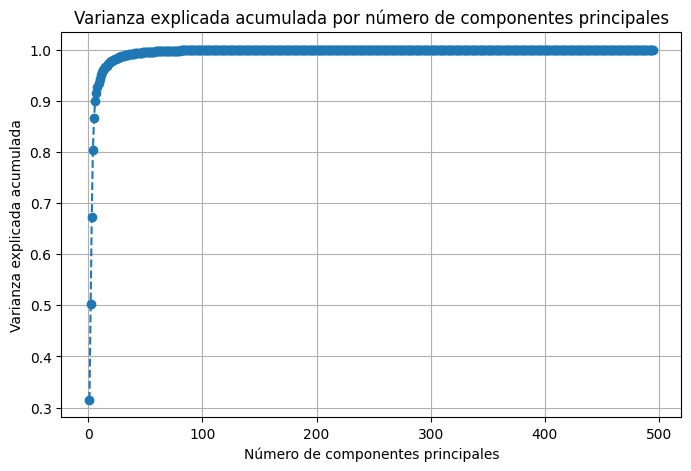

In [32]:
#Calcular la varianza explicada acumulada
data_2=result_df.drop('label', axis=1)
X = StandardScaler().fit_transform(data_2)
pca = PCA()  # Reduce to 2 dimensions for visualization
pca.fit(X)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

#Imprimir la varianza explicada por cada componente principal
print("Varianza explicada por cada componente principal:")
for i, var_exp in enumerate(explained_variance_ratio):
  if var_exp > 0.001:
    print(f"Componente {i + 1}: {var_exp:.4f}")

#Graficar la varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza explicada acumulada por número de componentes principales')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.show()

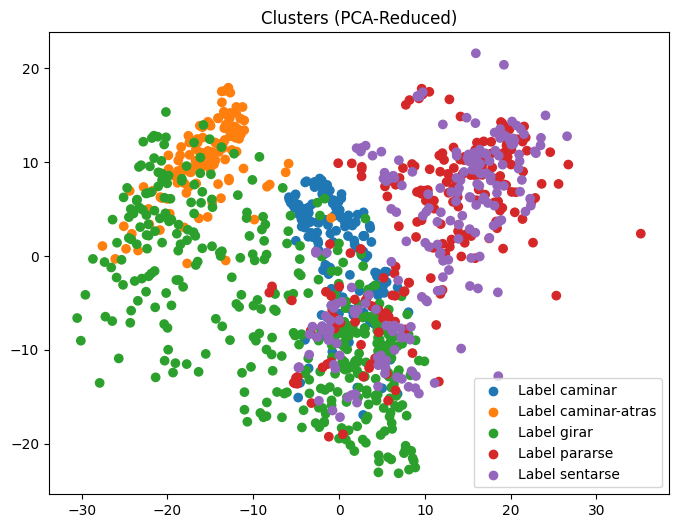

In [33]:
labels = result_df['label']

data_2=result_df.drop('label', axis=1)

X = StandardScaler().fit_transform(data_2)

pca = PCA(n_components=20)  # Reduce to 2 dimensions for visualization
reduced_data = pca.fit_transform(X)

# Create a color map for each unique label
unique_labels = labels.unique()
label_colors = {label: plt.get_cmap('tab10')(i) for i, label in enumerate(unique_labels)}

# Assign colors to data points based on their labels
colors = [label_colors[label] for label in labels]


plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=colors)
plt.title("Clusters (PCA-Reduced)")

# Create a legend to show which color represents each label
for label, color in label_colors.items():
  plt.scatter([], [], color=color, label=f'Label {label}')

plt.legend()
plt.show()

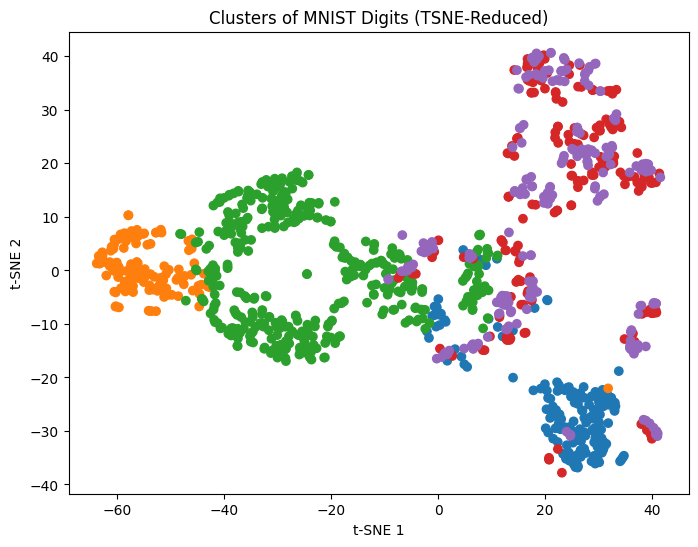

In [34]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, init='pca')
tsne_features = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=colors)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title("Clusters of MNIST Digits (TSNE-Reduced)")

# Create a legend to show which color represents each label
for label, color in label_colors.items():
  plt.scatter([], [], color=color, label=f'Label {label}')

Varianza explicada por cada componente principal:
Componente 1: 0.3151
Componente 2: 0.1868
Componente 3: 0.1701
Componente 4: 0.1304
Componente 5: 0.0633
Componente 6: 0.0332
Componente 7: 0.0164
Componente 8: 0.0108
Componente 9: 0.0086
Componente 10: 0.0082
Componente 11: 0.0077
Componente 12: 0.0043
Componente 13: 0.0041
Componente 14: 0.0033
Componente 15: 0.0030
Componente 16: 0.0028
Componente 17: 0.0023
Componente 18: 0.0022
Componente 19: 0.0020
Componente 20: 0.0016
Componente 21: 0.0014
Componente 22: 0.0014
Componente 23: 0.0012
Componente 24: 0.0011
Componente 25: 0.0011


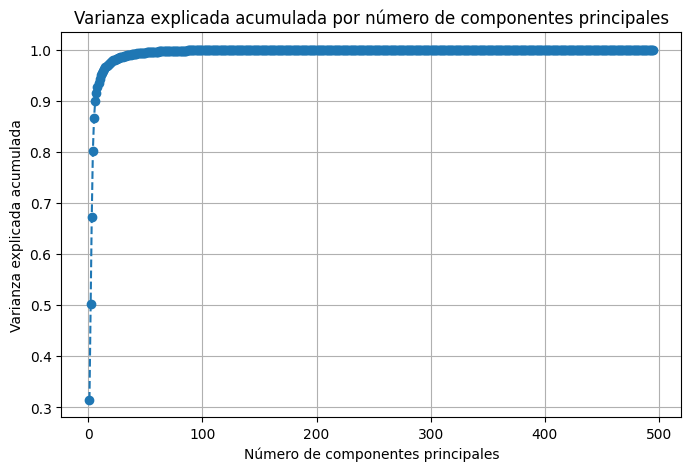

In [35]:
#Calcular la varianza explicada acumulada
data_2=result_df_2.drop('label', axis=1)
X = StandardScaler().fit_transform(data_2)
pca = PCA()  # Reduce to 2 dimensions for visualization
pca.fit(X)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

#Imprimir la varianza explicada por cada componente principal
print("Varianza explicada por cada componente principal:")
for i, var_exp in enumerate(explained_variance_ratio):
  if var_exp > 0.001:
    print(f"Componente {i + 1}: {var_exp:.4f}")

#Graficar la varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza explicada acumulada por número de componentes principales')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.show()

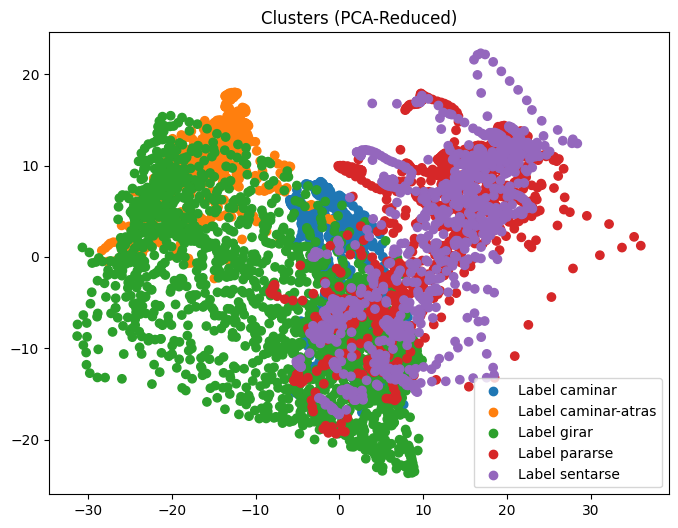

In [36]:
labels = result_df_2['label']

data_2=result_df_2.drop('label', axis=1)

X = StandardScaler().fit_transform(data_2)

pca = PCA(n_components=20)  # Reduce to 2 dimensions for visualization
reduced_data = pca.fit_transform(X)

# Create a color map for each unique label
unique_labels = labels.unique()
label_colors = {label: plt.get_cmap('tab10')(i) for i, label in enumerate(unique_labels)}

# Assign colors to data points based on their labels
colors = [label_colors[label] for label in labels]


plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=colors)
plt.title("Clusters (PCA-Reduced)")

# Create a legend to show which color represents each label
for label, color in label_colors.items():
  plt.scatter([], [], color=color, label=f'Label {label}')

plt.legend()
plt.show()

In [37]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Separar las características (X) y las etiquetas (y)
X = result_df_2.drop(columns=['label'])
y = result_df_2['label']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear una instancia del modelo SVC
svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

# Entrenar el modelo
svm_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_svm = svm_model.predict(X_test)

# Evaluar el modelo
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

print(f'SVM Accuracy: {accuracy_svm}')
print('SVM Classification Report:')
print(report_svm)

SVM Accuracy: 0.907942238267148
SVM Classification Report:
               precision    recall  f1-score   support

      caminar       0.97      0.95      0.96       274
caminar-atras       1.00      0.98      0.99       189
        girar       0.95      1.00      0.97       576
      pararse       0.80      0.81      0.80       303
     sentarse       0.83      0.76      0.79       320

     accuracy                           0.91      1662
    macro avg       0.91      0.90      0.90      1662
 weighted avg       0.91      0.91      0.91      1662



In [38]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Separar las características (X) y las etiquetas (y)
X = result_df_2.drop(columns=['label'])
y = result_df_2['label']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear una instancia del modelo SVC
svm_model = SVC(random_state=42)

# Definir los parámetros para el GridSearch con opciones menos amplias
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Crear una instancia de GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Realizar la búsqueda de hiperparámetros
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros
best_params = grid_search.best_params_
print(f"Mejores parámetros: {best_params}")

# Entrenar el modelo con los mejores parámetros
best_model = grid_search.best_estimator_    

# Realizar predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Mejores parámetros: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Accuracy: 0.9915764139590855
Classification Report:
               precision    recall  f1-score   support

      caminar       1.00      1.00      1.00       274
caminar-atras       1.00      1.00      1.00       189
        girar       1.00      1.00      1.00       576
      pararse       0.98      0.98      0.98       303
     sentarse       0.98      0.98      0.98       320

     accuracy                           0.99      1662
    macro avg       0.99      0.99      0.99      1662
 weighted avg       0.99      0.99      0.99      1662



In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Separar las características (X) y las etiquetas (y)
X = result_df_2.drop(columns=['label'])
y = result_df_2['label']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear una instancia del modelo RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=9, random_state=42)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f'RandomForestClassifier Accuracy: {accuracy_rf}')
print('RandomForestClassifier Classification Report:')
print(report_rf)

RandomForestClassifier Accuracy: 0.9813477737665464
RandomForestClassifier Classification Report:
               precision    recall  f1-score   support

      caminar       0.99      0.97      0.98       274
caminar-atras       1.00      0.97      0.99       189
        girar       0.98      1.00      0.99       576
      pararse       0.99      0.95      0.97       303
     sentarse       0.95      0.99      0.97       320

     accuracy                           0.98      1662
    macro avg       0.98      0.98      0.98      1662
 weighted avg       0.98      0.98      0.98      1662



In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Separar las características (X) y las etiquetas (y)
X = result_df_2.drop(columns=['label'])
y = result_df_2['label']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear una instancia del modelo RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Definir los parámetros para el GridSearch con opciones menos amplias
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [9, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Crear una instancia de GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Realizar la búsqueda de hiperparámetros
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros
best_params = grid_search.best_params_
print(f"Mejores parámetros: {best_params}")

# Entrenar el modelo con los mejores parámetros
best_model = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Mejores parámetros: {'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.9891696750902527
Classification Report:
               precision    recall  f1-score   support

      caminar       1.00      0.99      0.99       274
caminar-atras       1.00      0.97      0.99       189
        girar       0.98      1.00      0.99       576
      pararse       0.99      0.98      0.99       303
     sentarse       0.98      0.99      0.98       320

     accuracy                           0.99      1662
    macro avg       0.99      0.99      0.99      1662
 weighted avg       0.99      0.99      0.99      1662



In [44]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Separar las características (X) y las etiquetas (y)
X = result_df_2.drop(columns=['label'])
y = result_df_2['label']

# Codificar las etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Crear una instancia del modelo XGBClassifier
model = xgb.XGBClassifier(
    eval_metric='mlogloss',
    n_estimators=100,  # Número de árboles
    max_depth=6,  # Profundidad máxima de los árboles
    scale_pos_weight=1,
    learning_rate=0.1)

# Entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

C:\Users\santy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [20:15:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9963898916967509
Classification Report:
               precision    recall  f1-score   support

      caminar       1.00      0.99      0.99       274
caminar-atras       1.00      1.00      1.00       189
        girar       0.99      1.00      1.00       576
      pararse       1.00      0.99      1.00       303
     sentarse       0.99      1.00      1.00       320

     accuracy                           1.00      1662
    macro avg       1.00      1.00      1.00      1662
 weighted avg       1.00      1.00      1.00      1662



In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Separar las características (X) y las etiquetas (y)
X = result_df_2.drop(columns=['label'])
y = result_df_2['label']

# Codificar las etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Crear una instancia del modelo XGBClassifier
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Definir los parámetros para el GridSearch con opciones menos amplias
param_grid = {
    'n_estimators': [200],
    'max_depth': [9],
    'scale_pos_weight': [1, 1.5, 2, 2.5],
    'learning_rate': [0.01, 0.05, 0.1, 0.15]
}

# Crear una instancia de GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Realizar la búsqueda de hiperparámetros
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros
best_params = grid_search.best_params_
print(f"Mejores parámetros: {best_params}")

# Entrenar el modelo con los mejores parámetros
best_model = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
